In [7]:
# 1. 导入必要的库
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import h5py
import random
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import pandas as pd
from einops import rearrange, reduce, repeat
from einops.layers.torch import Rearrange, Reduce
import json
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子以确保可重复性
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [8]:
# 2. 模型定义
class EEGConformer(nn.Module):
    """EEG Conformer 模型适配中文EEG数据集"""
    
    def __init__(self, emb_size=40, depth=4, n_classes=2, dropout_rate=0.5):
        super(EEGConformer, self).__init__()
        
        # Patch Embedding
        self.patch_embedding = nn.Sequential(
            nn.Conv2d(1, 40, kernel_size=(1, 13), stride=(1, 1), padding=(0, 6)),
            nn.BatchNorm2d(40),
            nn.ELU(),
            nn.Dropout2d(0.3),
            
            nn.Conv2d(40, 40, kernel_size=(22, 1), stride=(1, 1)),
            nn.BatchNorm2d(40),
            nn.ELU(),
            nn.Dropout2d(0.3),
            
            nn.AvgPool2d(kernel_size=(1, 10), stride=(1, 5)),
            nn.Conv2d(40, emb_size, kernel_size=(1, 1)),
            Rearrange('b e (h) (w) -> b (h w) e'),
        )
        
        self.position_embedding = nn.Parameter(torch.randn(1, 100, emb_size))
        
        # Transformer Encoder
        self.transformer_encoder = nn.ModuleList([
            TransformerBlock(emb_size, num_heads=8, dropout_rate=dropout_rate)
            for _ in range(depth)
        ])
        
        # 分类头
        self.classifier = ClassificationHead(emb_size, n_classes)
        
    def forward(self, x):
        x = self.patch_embedding(x)
        # print(f"Patch embedding输出形状: {x.shape}")  # 应该看到 (batch, ?, emb_size)
        # print(f"位置编码形状: {self.position_embedding.shape}")
        x = x + self.position_embedding[:, :x.size(1), :]
        
        for transformer_block in self.transformer_encoder:
            x = transformer_block(x)
        
        x, logits = self.classifier(x)
        return x, logits


class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size, num_heads, dropout_rate):
        super().__init__()
        self.emb_size = emb_size
        self.num_heads = num_heads
        self.head_dim = emb_size // num_heads
        
        assert self.head_dim * num_heads == emb_size, "emb_size必须能被num_heads整除"
        
        self.q_linear = nn.Linear(emb_size, emb_size)
        self.k_linear = nn.Linear(emb_size, emb_size)
        self.v_linear = nn.Linear(emb_size, emb_size)
        
        self.dropout = nn.Dropout(dropout_rate)
        self.out_linear = nn.Linear(emb_size, emb_size)
        
    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.shape
        
        Q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        K = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        V = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        attention = F.softmax(scores, dim=-1)
        attention = self.dropout(attention)
        
        out = torch.matmul(attention, V)
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.emb_size)
        out = self.out_linear(out)
        
        return out


class TransformerBlock(nn.Module):
    def __init__(self, emb_size, num_heads, dropout_rate, expansion=4):
        super().__init__()
        
        self.attention = nn.Sequential(
            nn.LayerNorm(emb_size),
            MultiHeadAttention(emb_size, num_heads, dropout_rate),
            nn.Dropout(dropout_rate)
        )
        
        self.feed_forward = nn.Sequential(
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size, emb_size * expansion),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(emb_size * expansion, emb_size),
            nn.Dropout(dropout_rate)
        )
        
    def forward(self, x):
        x = x + self.attention(x)
        x = x + self.feed_forward(x)
        return x


# 修改ClassificationHead类
class ClassificationHead(nn.Module):
    def __init__(self, emb_size, n_classes):
        super().__init__()
        
        # 修改1: 移除LayerNorm
        self.global_pool = nn.Sequential(
            # nn.LayerNorm(emb_size),  # 移除这行
            nn.AdaptiveAvgPool1d(1),  # 全局平均池化
            Rearrange('b e 1 -> b e')
        )
        
        # 修改2: 在分类器开头添加LayerNorm
        self.classifier = nn.Sequential(
            nn.LayerNorm(emb_size),  # 添加在这里
            nn.Linear(emb_size, 128),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )
        
    def forward(self, x):
        # x形状: (batch, seq_len, emb_size)
        # 修改3: 正确处理转置
        pooled = self.global_pool(x.transpose(1, 2))  # 转换为 (batch, emb_size, seq_len)
        
        # 分类
        logits = self.classifier(pooled)
        
        return pooled, logits

In [9]:
# 3. H5 data loader
class H5Dataset(Dataset):
    """加载H5格式的EEG数据集"""
    
    def __init__(self, h5_path, has_labels=True, normalize=True):
        """
        参数:
            h5_path: H5文件路径
            has_labels: 文件是否包含标签
            normalize: 是否对数据进行标准化
        """
        self.h5_path = h5_path
        self.has_labels = has_labels
        self.normalize = normalize
        
        # 加载数据
        with h5py.File(h5_path, 'r') as f:
            # 查看H5文件中的数据集
            print(f"文件 {h5_path} 中的数据集: {list(f.keys())}")
            
            # 尝试不同的键名
            data_keys = ['X', 'data', 'eeg', 'features', 'x']
            label_keys = ['y', 'labels', 'label', 'Y']
            
            # 查找数据
            data_key = None
            for key in data_keys:
                if key in f:
                    data_key = key
                    break
            
            if data_key is None:
                raise ValueError(f"在 {h5_path} 中未找到数据，可用的键: {list(f.keys())}")
            
            self.data = f[data_key][:]
            print(f"数据形状: {self.data.shape}")
            
            # 查找标签
            if has_labels:
                label_key = None
                for key in label_keys:
                    if key in f:
                        label_key = key
                        break
                
                if label_key is None:
                    raise ValueError(f"在 {h5_path} 中未找到标签，可用的键: {list(f.keys())}")
                
                self.labels = f[label_key][:]
                print(f"标签形状: {self.labels.shape}")
                print(f"标签分布: {np.bincount(self.labels.flatten().astype(int))}")
            else:
                self.labels = None
        
        # 重塑数据格式 (如果需要)
        if len(self.data.shape) == 3:  # 假设形状是 (samples, channels, time)
            # 添加通道维度: (samples, channels, time) -> (samples, 1, channels, time)
            self.data = np.expand_dims(self.data, axis=1)
        elif len(self.data.shape) == 2:  # 假设形状是 (samples, channels*time)
            # 需要知道原始形状
            print("警告: 数据是2D的，需要重塑")
            # 这里需要根据实际情况调整
            # 假设每个样本是 channels * time
            # 需要知道channels和time的值
            # 对于你的数据，可能是 22 * 200 = 4400
            if self.data.shape[1] == 4400:  # 22通道 * 200时间点
                self.data = self.data.reshape(-1, 1, 22, 200)
            else:
                print(f"无法自动重塑数据，形状: {self.data.shape}")
        
        print(f"重塑后数据形状: {self.data.shape}")
        
        # 标准化
        if normalize:
            self._normalize()
    
    def _normalize(self):
        """标准化数据"""
        # 对每个通道单独标准化
        for i in range(self.data.shape[0]):
            for j in range(self.data.shape[2]):  # 电极通道
                self.data[i, 0, j, :] = (self.data[i, 0, j, :] - np.mean(self.data[i, 0, j, :])) / (np.std(self.data[i, 0, j, :]) + 1e-8)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        eeg = torch.FloatTensor(self.data[idx])
        
        if self.has_labels:
            label = torch.LongTensor([self.labels[idx].flatten()[0]])[0]
            return eeg, label
        else:
            return eeg

In [10]:
# 4. 模型训练器
class EEGConformerTrainer:
    def __init__(self, model, device='cuda', lr=1e-4, weight_decay=1e-4):
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(
            model.parameters(), 
            lr=lr, 
            weight_decay=weight_decay
        )
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='max', factor=0.5, patience=5, verbose=True
        )
        
    def train_epoch(self, train_loader):
        """训练一个epoch"""
        self.model.train()
        total_loss = 0
        all_preds = []
        all_labels = []
        
        for batch_idx, (eeg, labels) in enumerate(train_loader):
            eeg, labels = eeg.to(self.device), labels.to(self.device)
            
            # 前向传播
            self.optimizer.zero_grad()
            _, outputs = self.model(eeg)
            loss = self.criterion(outputs, labels)
            
            # 反向传播
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            
            # 记录指标
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        
        epoch_loss = total_loss / len(train_loader)
        epoch_acc = accuracy_score(all_labels, all_preds)
        
        return epoch_loss, epoch_acc
    
    def validate(self, val_loader):
        """验证"""
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for eeg, labels in val_loader:
                eeg, labels = eeg.to(self.device), labels.to(self.device)
                
                # 前向传播
                _, outputs = self.model(eeg)
                loss = self.criterion(outputs, labels)
                
                # 记录
                total_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        epoch_loss = total_loss / len(val_loader)
        epoch_acc = accuracy_score(all_labels, all_preds)
        
        return epoch_loss, epoch_acc, all_preds, all_labels
    
    def predict(self, test_loader):
        """预测（无标签）"""
        self.model.eval()
        all_preds = []
        all_probs = []
        
        with torch.no_grad():
            for eeg in tqdm(test_loader, desc="预测"):
                eeg = eeg.to(self.device)
                
                # 前向传播
                _, outputs = self.model(eeg)
                probs = F.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                
                all_preds.extend(predicted.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
        
        return np.array(all_preds), np.array(all_probs)
    
    def save_model(self, path):
        """保存模型"""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
        }, path)
    
    def load_model(self, path):
        """加载模型"""
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

In [11]:
# 5. 主训练流程
def train_and_evaluate(train_path, val_path, test_path, config):
    """主训练和评估函数 - 无进度条版本"""
    
    # 设置设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")
    print(f"PyTorch版本: {torch.__version__}")
    print(f"CUDA可用: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    
    # 加载数据
    print("\n" + "="*50)
    print("加载训练数据...")
    train_dataset = H5Dataset(train_path, has_labels=True, normalize=True)
    
    print("\n加载验证数据...")
    val_dataset = H5Dataset(val_path, has_labels=True, normalize=True)
    
    print("\n加载测试数据...")
    test_dataset = H5Dataset(test_path, has_labels=False, normalize=True)
    
    # 创建数据加载器
    train_loader = DataLoader(
        train_dataset, 
        batch_size=config['batch_size'], 
        shuffle=True, 
        num_workers=2,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=config['batch_size'], 
        shuffle=False, 
        num_workers=2
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=config['batch_size'], 
        shuffle=False, 
        num_workers=2
    )
    
    # 创建模型
    model = EEGConformer(
        emb_size=config['emb_size'],
        depth=config['depth'],
        n_classes=config['n_classes'],
        dropout_rate=config['dropout_rate']
    )
    
    # 创建训练器（使用无进度条版本）
    trainer = EEGConformerTrainer(
        model, 
        device=device,
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    
    # 训练
    print("\n" + "="*50)
    print("开始训练...")
    print(f"训练样本数: {len(train_dataset)}")
    print(f"验证样本数: {len(val_dataset)}")
    print(f"测试样本数: {len(test_dataset)}")
    
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    
    best_val_acc = 0
    best_epoch = 0
    
    for epoch in range(config['num_epochs']):
        # 只在特定轮次显示epoch标题
        if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == config['num_epochs'] - 1:
            print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
            print("-" * 30)
        
        # 训练
        train_loss, train_acc = trainer.train_epoch(train_loader)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # 验证
        val_loss, val_acc, val_preds, val_labels = trainer.validate(val_loader)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # 学习率调整
        trainer.scheduler.step(val_acc)
        
        # 只在每10轮、第1轮和最后1轮打印详细结果
        if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == config['num_epochs'] - 1:
            print(f"训练损失: {train_loss:.4f}, 训练准确率: {train_acc:.4f}")
            print(f"验证损失: {val_loss:.4f}, 验证准确率: {val_acc:.4f}")
        
        # 保存最佳模型
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            trainer.save_model('best_model.pth')
            # 只在打印详细结果时显示保存信息
            if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == config['num_epochs'] - 1:
                print(f"✓ 保存最佳模型 (验证准确率: {val_acc:.4f})")
    
    # 测试
    print("\n" + "="*50)
    print("测试最佳模型...")
    trainer.load_model('best_model.pth')
    
    # 在验证集上评估最佳模型
    val_loss, val_acc, val_preds, val_labels = trainer.validate(val_loader)
    
    print(f"最终验证结果 - 损失: {val_loss:.4f}, 准确率: {val_acc:.4f}")
    
    # 打印分类报告
    print("\n验证集分类报告:")
    print(classification_report(val_labels, val_preds, target_names=['No-Reading', 'Reading']))
    print(f"F1分数: {f1_score(val_labels, val_preds, average='weighted'):.4f}")
    
    # 对测试集进行预测
    print("\n" + "="*50)
    print("对测试集进行预测...")
    test_predictions, test_probabilities = trainer.predict(test_loader)
    
    # 保存预测结果
    np.save('test_predictions.npy', test_predictions)
    np.save('test_probabilities.npy', test_probabilities)
    
    # 保存为txt文件 (0/1格式)
    with open('test_predictions.txt', 'w') as f:
        for pred in test_predictions:
            f.write(f"{int(pred)}\n")
    
    print(f"测试集预测结果已保存:")
    print(f"  - test_predictions.npy: 包含所有预测 (0/1)")
    print(f"  - test_probabilities.npy: 包含预测概率")
    print(f"  - test_predictions.txt: 纯文本格式，每行一个预测 (0/1)")
    
    # 打印预测统计
    print(f"\n测试集预测统计:")
    unique, counts = np.unique(test_predictions, return_counts=True)
    for label, count in zip(unique, counts):
        label_name = "Reading" if label == 1 else "No-Reading"
        print(f"  {label_name} ({label}): {count} 个样本 ({count/len(test_predictions)*100:.1f}%)")
    
    # 绘制训练曲线
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(train_losses, label='train loss', marker='o', markersize=3)
    axes[0].plot(val_losses, label='val loss', marker='s', markersize=3)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(train_accs, label='train accuracy', marker='o', markersize=3)
    axes[1].plot(val_accs, label='val accuracy', marker='s', markersize=3)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 绘制混淆矩阵
    cm = confusion_matrix(val_labels, val_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No-Reading', 'Reading'], 
                yticklabels=['No-Reading', 'Reading'])
    plt.title('Validation Confusion Matrix')
    plt.ylabel('True Labels')
    plt.xlabel('Predicted Labels')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 保存训练结果汇总
    results = {
        'best_epoch': best_epoch + 1,
        'best_val_accuracy': float(best_val_acc),
        'final_val_accuracy': float(val_acc),
        'final_val_loss': float(val_loss),
        'train_losses': [float(x) for x in train_losses],
        'train_accuracies': [float(x) for x in train_accs],
        'val_losses': [float(x) for x in val_losses],
        'val_accuracies': [float(x) for x in val_accs],
        'test_predictions': test_predictions.tolist(),
        'test_predictions_summary': {
            'total_samples': len(test_predictions),
            'num_no_reading': int((test_predictions == 0).sum()),
            'num_reading': int((test_predictions == 1).sum()),
            'percentage_no_reading': float((test_predictions == 0).sum() / len(test_predictions) * 100),
            'percentage_reading': float((test_predictions == 1).sum() / len(test_predictions) * 100)
        }
    }
    
    with open('training_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print("\n训练结果已保存到 training_results.json")
    
    return trainer, test_predictions, val_acc, val_loss

EEG Conformer 配置:
  emb_size: 40
  depth: 8
  n_classes: 2
  dropout_rate: 0.3
  batch_size: 64
  learning_rate: 0.0001
  weight_decay: 1e-05
  num_epochs: 50
使用设备: cuda
PyTorch版本: 1.12.1+cu116
CUDA可用: True
GPU: NVIDIA GeForce RTX 3090

加载训练数据...
文件 data/CHINESE/train.h5 中的数据集: ['X', 'y']
数据形状: (400, 22, 200)
标签形状: (400,)
标签分布: [200 200]
重塑后数据形状: (400, 1, 22, 200)

加载验证数据...
文件 data/CHINESE/val.h5 中的数据集: ['X', 'y']
数据形状: (200, 22, 200)
标签形状: (200,)
标签分布: [100 100]
重塑后数据形状: (200, 1, 22, 200)

加载测试数据...
文件 data/CHINESE/test_x_only.h5 中的数据集: ['X']
数据形状: (200, 22, 200)
重塑后数据形状: (200, 1, 22, 200)

开始训练...
训练样本数: 400
验证样本数: 200
测试样本数: 200

Epoch 1/50
------------------------------
训练损失: 0.7087, 训练准确率: 0.4750
验证损失: 0.6912, 验证准确率: 0.5550
✓ 保存最佳模型 (验证准确率: 0.5550)

Epoch 10/50
------------------------------
训练损失: 0.6729, 训练准确率: 0.5850
验证损失: 0.6802, 验证准确率: 0.6050

Epoch 20/50
------------------------------
训练损失: 0.6405, 训练准确率: 0.6550
验证损失: 0.6917, 验证准确率: 0.5950
Epoch 00022: reducing learning rate

预测:   0%|          | 0/4 [00:00<?, ?it/s]

测试集预测结果已保存:
  - test_predictions.npy: 包含所有预测 (0/1)
  - test_probabilities.npy: 包含预测概率
  - test_predictions.txt: 纯文本格式，每行一个预测 (0/1)

测试集预测统计:
  No-Reading (0): 94 个样本 (47.0%)
  Reading (1): 106 个样本 (53.0%)


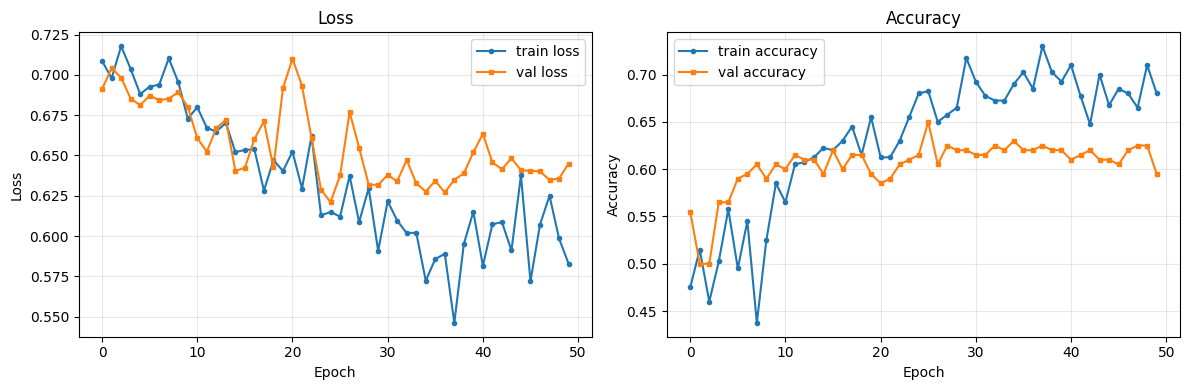

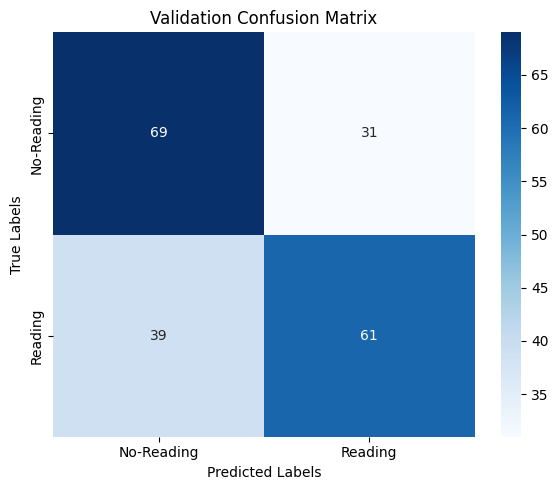


训练结果已保存到 training_results.json

训练完成!
最终验证准确率: 0.6500
最终验证损失: 0.6377
测试集预测已保存到 test_predictions.txt


In [12]:
# 6. 配置和运行
if __name__ == "__main__":
    # 配置参数
    config = {
        'emb_size': 40,           # 嵌入维度
        'depth': 8,              # Transformer层数
        'n_classes': 2,          # 二分类
        'dropout_rate': 0.3,     # Dropout比率
        'batch_size': 64,        # 批次大小
        'learning_rate': 1e-4,   # 学习率
        'weight_decay': 1e-5,    # 权重衰减
        'num_epochs': 50,        # 训练轮数
    }
    
    # 打印配置
    print("EEG Conformer 配置:")
    for key, value in config.items():
        print(f"  {key}: {value}")
    

    # 文件路径
    train_path = "data/CHINESE/train.h5"  # 训练集
    val_path = "data/CHINESE/val.h5"      # 验证集
    test_path = "data/CHINESE/test_x_only.h5"  # 测试集（只有特征）
    
    # 训练和评估模型
    try:
        trainer, test_predictions, val_acc, val_loss = train_and_evaluate(
            train_path, val_path, test_path, config
        )
        
        print("\n" + "="*50)
        print("训练完成!")
        print(f"最终验证准确率: {val_acc:.4f}")
        print(f"最终验证损失: {val_loss:.4f}")
        print(f"测试集预测已保存到 test_predictions.txt")
        
    except Exception as e:
        print(f"训练过程中发生错误: {e}")
        import traceback
        traceback.print_exc()

In [13]:
# 7. 辅助函数
def load_predictions():
    """加载预测结果"""
    if os.path.exists('test_predictions.txt'):
        predictions = np.loadtxt('test_predictions.txt', dtype=int)
        print(f"加载了 {len(predictions)} 个预测结果")
        print(f"预测分布: {np.bincount(predictions)}")
        return predictions
    else:
        print("预测文件不存在")
        return None

def visualize_sample_predictions(trainer, test_dataset, num_samples=5):
    """可视化一些测试样本的预测"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trainer.model.eval()
    trainer.model.to(device)
    
    # 创建测试数据加载器
    test_loader = DataLoader(test_dataset, batch_size=num_samples, shuffle=True)
    
    # 获取一些样本
    eeg_samples = next(iter(test_loader))
    if isinstance(eeg_samples, tuple):  # 如果有标签
        eeg_samples, _ = eeg_samples
    
    eeg_samples = eeg_samples[:num_samples].to(device)
    
    # 获取预测
    with torch.no_grad():
        _, outputs = trainer.model(eeg_samples)
        probabilities = F.softmax(outputs, dim=1)
        _, predictions = torch.max(outputs, 1)
    
    # 绘制EEG信号和预测结果
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 3*num_samples))
    
    for i in range(min(num_samples, len(eeg_samples))):
        # 绘制EEG信号
        eeg_data = eeg_samples[i, 0].cpu().numpy()
        
        axes[i, 0].imshow(eeg_data, aspect='auto', cmap='RdBu_r', interpolation='none')
        axes[i, 0].set_title(f'测试样本 {i+1}')
        axes[i, 0].set_xlabel('时间点')
        axes[i, 0].set_ylabel('通道')
        plt.colorbar(axes[i, 0].imshow(eeg_data, aspect='auto', cmap='RdBu_r'), ax=axes[i, 0])
        
        # 显示预测结果
        pred_label = 'Reading' if predictions[i].item() == 1 else 'No-Reading'
        prob_reading = probabilities[i, 1].item() * 100
        prob_no_reading = probabilities[i, 0].item() * 100
        
        axes[i, 1].text(0.5, 0.5, 
                       f'预测: {pred_label}\n'
                       f'Reading概率: {prob_reading:.1f}%\n'
                       f'No-Reading概率: {prob_no_reading:.1f}%', 
                       ha='center', va='center', fontsize=10)
        axes[i, 1].axis('off')
        axes[i, 1].set_title('预测结果')
    
    plt.tight_layout()
    plt.show()